(20, 4)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


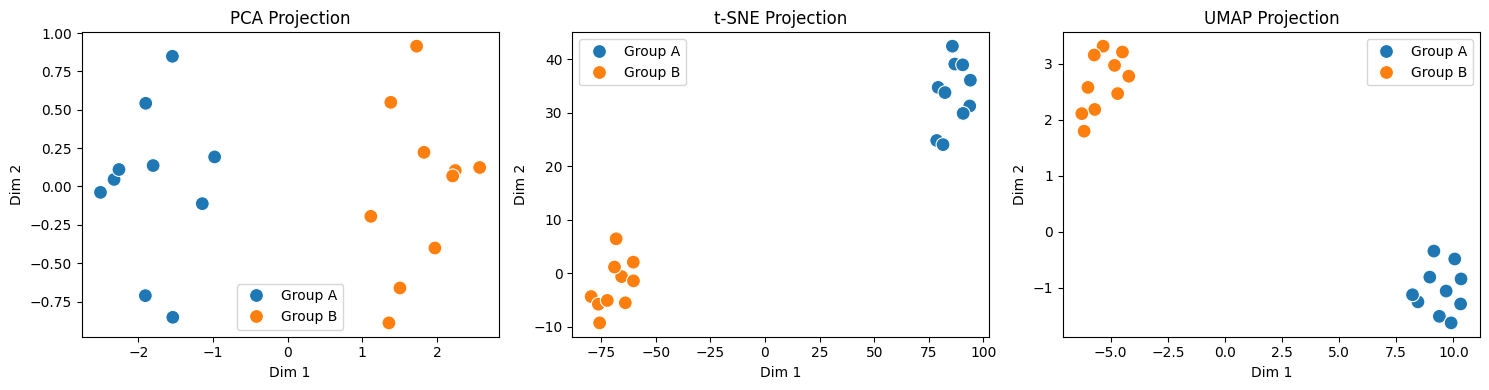

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
# --- DATASET GENERATION (Do not change) ---
np.random.seed(42)
data = np.random.randn(20, 4)
data[10:, :] += 3.5 # Create 2 groups
labels = ['Group A']*10 + ['Group B']*10
df = pd.DataFrame(data, columns=['F1', 'F2', 'F3', 'F4'])
print(df.shape)
X_scaled = StandardScaler().fit_transform(df)
# PCA
pca_res = PCA(n_components=2).fit_transform(X_scaled)
tsne_res = TSNE(n_components=2, perplexity=4,
random_state=42).fit_transform(X_scaled)
# UMAP
umap_res = umap.UMAP(n_components=2, n_neighbors=5,
random_state=42).fit_transform(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
results = [('PCA', pca_res), ('t-SNE', tsne_res), ('UMAP', umap_res)]
for ax, (title, res_data) in zip(axes, results):
  plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])
  sns.scatterplot(data=plot_df, x='Dim 1', y='Dim 2', ax=ax, s=100, hue=labels)
  ax.set_title(f"{title} Projection")
plt.tight_layout()
plt.show()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
(150, 6)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


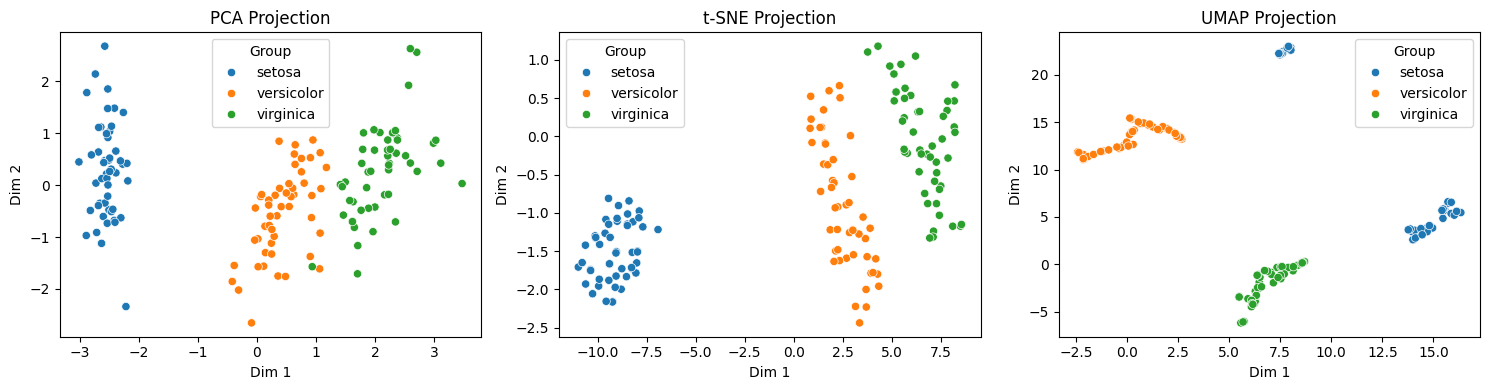

In [16]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame

iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
df['target'] = iris_raw.target
df['species'] = df['target'].map(dict(enumerate(iris_raw.target_names)))

print(df.head())
features = df.drop(columns=["species"])
labels = df["species"]
scalar = StandardScaler()
X_scaled = scalar.fit_transform(features)

pca_res = PCA(n_components=2).fit_transform(X_scaled)
print(df.shape)
tsne_res = TSNE(n_components=2, perplexity=50,
random_state=42).fit_transform(X_scaled)
umap_res = umap.UMAP(n_components=2, n_neighbors=5,
random_state=42).fit_transform(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
results = [('PCA', pca_res), ('t-SNE', tsne_res), ('UMAP', umap_res)]
for ax, (title, res_data) in zip(axes, results):
  plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])
  plot_df['Group'] = labels
  sns.scatterplot(data=plot_df, x='Dim 1', y='Dim 2', hue='Group', ax=ax)
  ax.set_title(f"{title} Projection")
plt.tight_layout()
plt.show()